# Imports
<div style="width:100%;height:0;border-bottom: 3px solid #F03A4F;margin-bottom: 1rem;"></div>

In [ ]:
!pip install ultralytics -q
!pip install -q albumentations
%env WANDB_DISABLED=True

In [ ]:
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import shutil
from PIL import Image
import torch
import random
import albumentations as A

seed = 42
np.random.seed(seed)
random.seed(seed)

# Preparing Dataset
<div style="width:100%;height:0;border-bottom: 3px solid #F27B40;margin-bottom: 1rem;"></div>

In [ ]:
base_dir = Path('/kaggle/input/kitti-dataset')
img_path = base_dir / 'data_object_image_2' / 'training' / 'image_2'
label_path = Path('/kaggle/input/kitti-dataset-yolo-format/labels')
with open('/kaggle/input/kitti-dataset-yolo-format/classes.json','r') as f:
    classes = json.load(f)

classes

In [ ]:
ims = sorted(list(img_path.glob('*')))
labels = sorted(list(label_path.glob('*')))
pairs = list(zip(ims,labels))
pairs[:2]

# Preparing File Structure
<div style="width:100%;height:0;border-bottom: 3px solid #F4B343;margin-bottom: 1rem;"></div>

```
/kaggle/working
    |
    -train
    |   |
    |   -000000.png
    |   -000000.txt
    |   ...
    |
    -val
      |
      -000001.png
      -000001.txt
      ...
```

In [ ]:
train, temp_imgs = train_test_split(pairs,test_size=0.2,random_state = 42)
val, test = train_test_split(temp_imgs, test_size=0.3, random_state=42)
len(train), len(val), len(test)

In [ ]:
train_path = Path('train').resolve()
train_path.mkdir(exist_ok=True)
valid_path = Path('valid').resolve()
valid_path.mkdir(exist_ok=True)

In [ ]:
for t_img, t_lb in tqdm(train):
    im_path = train_path / t_img.name
    lb_path = train_path / t_lb.name
    shutil.copy(t_img,im_path)
    shutil.copy(t_lb,lb_path)

In [ ]:
for t_img, t_lb in tqdm(val):
    im_path = valid_path / t_img.name
    lb_path = valid_path / t_lb.name
    shutil.copy(t_img,im_path)
    shutil.copy(t_lb,lb_path)

In [6]:
test_values = [img.name for img, _ in test[:50]]
# test_values

In [ ]:
test_values_complete = [img.name for img, _ in test]
# test_values_complete

# YAML file for the data
<div style="width:100%;height:0;border-bottom: 3px solid #F4CE45;margin-bottom: 1rem;"></div>

In [ ]:
yaml_file = 'names:\n'
yaml_file += '\n'.join(f'- {c}' for c in classes)
yaml_file += f'\nnc: {len(classes)}'
yaml_file += f'\ntrain: {str(train_path)}\nval: {str(valid_path)}'
with open('kitti.yaml','w') as f:
    f.write(yaml_file)

In [ ]:
!cat kitti.yaml

# Model
<div style="width:100%;height:0;border-bottom: 3px solid #F27B40;margin-bottom: 1rem;"></div>

In [ ]:
#model = YOLO('yolov8n.yaml')
model = YOLO('yolov8s.pt')

# Training
<div style="width:100%;height:0;border-bottom: 3px solid #F5E947;margin-bottom: 1rem;"></div>

In [ ]:
train_results = model.train(
    data='/kaggle/working/kitti.yaml', 
    epochs=40,
    imgsz=640,
    patience=3,
    mixup=0.1,
    project='yolov8n-kitti',
    device=0
)

# Validation
<div style="width:100%;height:0;border-bottom: 3px solid #E7F549;margin-bottom: 1rem;"></div>

In [ ]:
valid_results = model.val()

# Results
<div style="width:100%;height:0;border-bottom: 3px solid #F25F3E;margin-bottom: 1rem;"></div>

In [ ]:
plt.figure(figsize=(10,20))
plt.imshow(Image.open('/kaggle/working/yolov8n-kitti/train/results.png'))
plt.axis('off')
plt.show()

In [ ]:
plt.figure(figsize=(10,20))
plt.imshow(Image.open('/kaggle/working/yolov8n-kitti/train/confusion_matrix.png'))
plt.axis('off')
plt.show()

# Predictions
<div style="width:100%;height:0;border-bottom: 3px solid #CEF64B;margin-bottom: 1rem;"></div>

In [ ]:
import albumentations as A
print(A.__version__)

In [ ]:
items = 10
test_values1 = [img for img, _ in test[:items]]
test_labels1 = [_ for img, _ in test[:items]]
test_values1
test_labels1

In [34]:
original_images = []
noisy_images = []

In [ ]:
noise_transform = A.ReplayCompose([
    A.GaussNoise(var_limit=(0.1, 0.1), per_channel=True, p=1.0),
    A.MotionBlur(blur_limit=(3, 7), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.3, -0.2),
                               contrast_limit=(0.1, 0.3),
                               p=1.0)
], p=1.0)

for img_path in test_values1:
    # Load image
    print(str(img_path))
    image = np.array(Image.open(str(img_path)))
    
    # Apply augmentation
    augmented = noise_transform(image=image)
    noisy_image = augmented["image"]
    
    # Store in lists
    original_images.append(image)
    noisy_images.append(noisy_image)

In [36]:
len(original_images), len (noisy_images)

(10, 10)

In [ ]:
for i in range(min(5, len(original_images))):
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original_images[i])
    plt.axis("off")
    plt.title("Original")
    
    plt.subplot(1, 2, 2)
    plt.imshow(noisy_images[i])
    plt.axis("off")
    plt.title("Noisy/Augmented")
    
    plt.show()

In [39]:
def plot_images(images):
    num_images = len(images)
    fig, axes = plt.subplots(
        num_images, 1,
        figsize=(15, 4 * num_images)
    )

    if num_images == 1:
        axes = [axes]

    for ax, img_path in zip(axes, images):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=14, pad=4)
        ax.axis('off')

    plt.subplots_adjust(hspace=0.15)
    plt.show()


0: 224x640 4 Cars, 11.8ms
Speed: 2.6ms preprocess, 11.8ms inference, 1.5ms postprocess per image at shape (1, 3, 224, 640)
Results saved to /kaggle/working/runs/detect/predict2


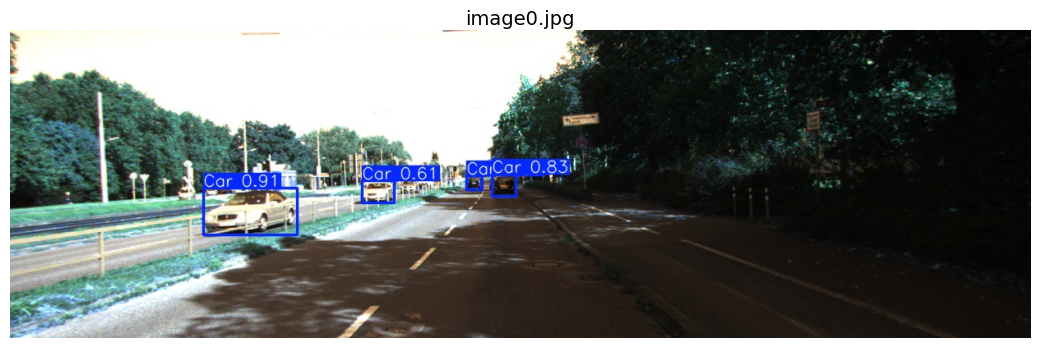

In [77]:
index_to_predict = 9
preds = model.predict(original_images[index_to_predict],save=True)
pred_img_path = [Path(preds[0].save_dir +'/' + preds[0].path)]
plot_images(pred_img_path)


0: 224x640 4 Cars, 9.1ms
Speed: 1.9ms preprocess, 9.1ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 640)
Results saved to /kaggle/working/runs/detect/predict2


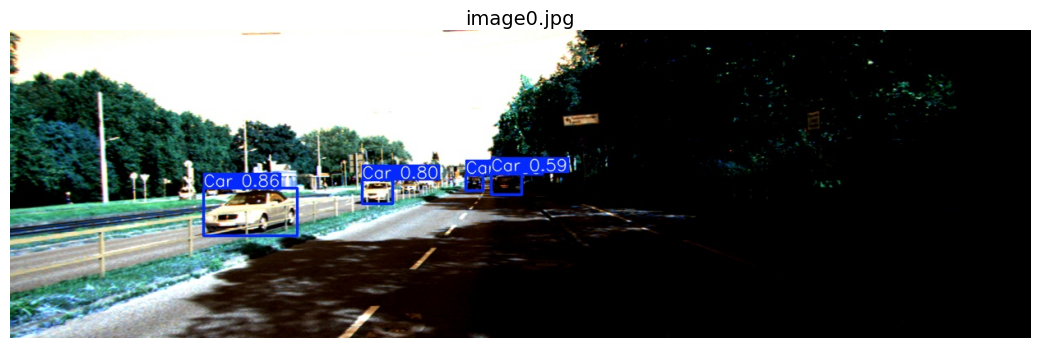

In [74]:
noisy_preds = model.predict(noisy_images[index_to_predict],save=True)
pred_img_path = [Path(preds[0].save_dir +'/' + preds[0].path)]
plot_images(pred_img_path)

In [ ]:
!cat {test_labels1[index_to_predict]}

## cleanup

In [ ]:
!cp /kaggle/working/yolov8n-kitti/train/weights/best.pt /kaggle/working/

In [ ]:
!zip -r results_camera_only.zip yolov8n-kitti

In [ ]:
!rm -rf /kaggle/working/*